In [ ]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
import numpy as np 
import pandas as pd
import datetime
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from zhiyi.analysis.SE_analysis import get_site_index 
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import matplotlib.patches as mpatches
print("done")


done


In [ ]:
SCRIP_file = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
SCRIP_file_ne60 ="/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
filebase_ne30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/'
                 'MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc')
start_date = datetime.date(2018, 6, 23)
end_date   = datetime.date(2018, 7, 2)

city_lonlat = {
    # 'London':    [360 - 0.213492,  51.521050],
    'Manchester':[360 - 2.237881, 53.481520],
    'Liverpool':[360 - 2.960989, 53.424225],
    'Sheffield':[360 - 1.455815, 53.404950],
    'Birmingham':[360 - 1.874978, 52.476145],
    # 'Edingurgh': [360 - 3.182186, 55.945589],
    # 'Glasgow':   [360 - 4.259122, 55.858940],
    # 'Birmingham': [360 - 1.874978, 52.476145],
    # 'Belfast':   [360 - 5.9301, 54.5973],
    # 'Glasgow':   [360 - 4.2576, 55.8651],
    # 'Bristol':   [360 - 2.5879, 51.4545],
}

In [ ]:

def collect_files(template, start, end):
    files = []
    by_day = ("DD" in template)
    cur = start
    while cur <= end:
        YYYY = cur.strftime("%Y")
        MM   = cur.strftime("%m")
        DD   = cur.strftime("%d")
        f = (template
             .replace("YYYY", YYYY)
             .replace("MM", MM)
             .replace("DD", DD))
        if os.path.exists(f):
            files.append(f)
        else:
            print(f"Warning: File not found - {f}, skipping.")
        if by_day:
            cur += datetime.timedelta(days=1)
        else:
            if cur.month == 12:
                cur = datetime.date(cur.year + 1, 1, 1)
            else:
                cur = datetime.date(cur.year, cur.month + 1, 1)
    if not files:
        raise FileNotFoundError(
            f"No files found for template '{template}' between {start} and {end}."
        )
    return files

def get_obs_series(obs_df, station_to_col, station, start, end):
    col = station_to_col[station]
    s = pd.to_numeric(obs_df[col], errors='coerce')
    return s[start:end]

def build_kdtree(ds):
    lon360 = ds['lon'].isel(time=0).values
    lat    = ds['lat'].isel(time=0).values
    lon180 = (lon360 + 180) % 360 - 180
    tree   = cKDTree(np.vstack([lat, lon180]).T)
    return tree, lon360, lat, lon180

def get_3x3_minmax(ds, tree, lon180_all, city_lon, city_lat, k=9):
    lon180_c = (city_lon + 180) % 360 - 180
    _, idx9  = tree.query([city_lat, lon180_c], k=k)
    pm9 = ds['PM25'][:, -1, idx9].values * 1e9
    return np.nanmin(pm9, axis=1), np.nanmax(pm9, axis=1)

scrip30 = xr.open_dataset(SCRIP_file)
se_files_30 = collect_files(filebase_ne30, start_date, end_date)
ds_ne30 = xr.open_mfdataset(se_files_30, combine="by_coords")

print("Datasets loaded!")

Datasets loaded!


In [ ]:

Index_lonlat_30 = {}
Index_lonlat_60 = {}

for city, (lon360_c, lat_c) in city_lonlat.items():
    Index_lonlat_30[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file
    )

TS     = {}
for city in city_lonlat:
    idx30 = Index_lonlat_30[city]
    TS[city]     = ds_ne30['CO'].values[:, -1, idx30] * 1e9
    # TS[city]     = ds_ne30['PM25'].values[:, -1, idx30] * 1e9
time_values      = pd.to_datetime(ds_ne30.time.values)


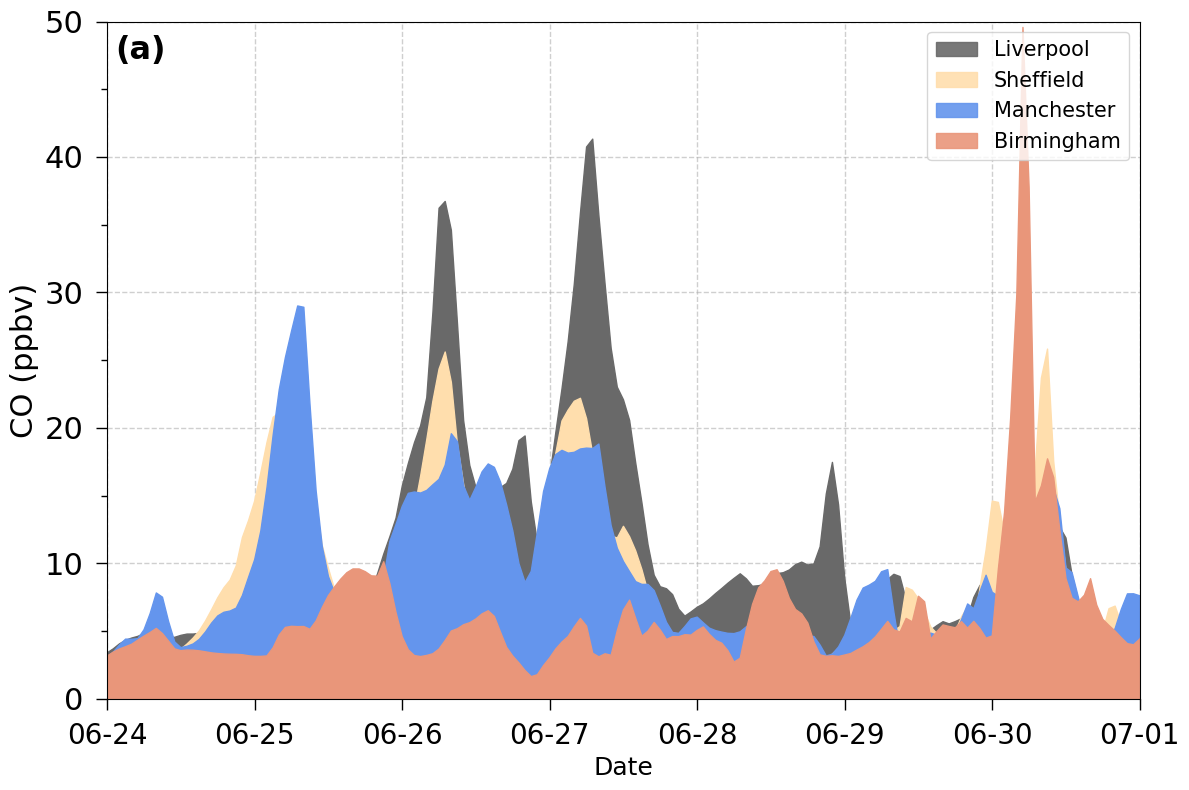

In [ ]:

cities = [ 'Liverpool','Sheffield','Manchester','Birmingham', ]
fig, ax = plt.subplots(figsize=(12, 8))
day_locator   = mdates.DayLocator(interval=1)
day_formatter = mdates.DateFormatter('%m-%d')
time_values_bst = (pd.to_datetime(time_values.astype('datetime64[ns]'))
                   .tz_localize('UTC')
                   .tz_convert('Europe/London'))

colors = ['dimgrey', 'navajowhite', 'cornflowerblue', 'darksalmon']
legend_handles = []

for i, city in enumerate(cities):
    color = colors[i % len(colors)]
    y = TS[city].squeeze()
    ax.fill_between(time_values_bst, y, 0,
                    color=color, alpha=1, label=city)
    legend_handles.append(mpatches.Patch(color=color, alpha=0.9, label=city))

ax.xaxis.set_major_locator(day_locator)
ax.xaxis.set_major_formatter(day_formatter)
plot_start_x = pd.Timestamp('2018-06-24')
plot_end_x   = pd.Timestamp('2018-07-01')
ax.set_xlim(pd.Timestamp(plot_start_x), pd.Timestamp(plot_end_x))

plt.setp(ax.get_xticklabels(), fontsize=18)
ax.tick_params(axis='x', which='major', labelsize=20, pad=9, length=8, width=1)
ax.tick_params(axis='x', which='minor', labelsize=16, length=4, width=1)
ax.set_xlabel('Date', fontsize=18)
ax.set_ylabel('CO (ppbv)', fontsize=22)
ax.yaxis.set_major_locator(MultipleLocator(10))   
ax.set_ylim(0, 50)
ax.yaxis.set_minor_locator(MultipleLocator(5))
ax.tick_params(axis='y', which='major', labelsize=22, pad=9, length=8, width=1)
ax.tick_params(axis='y', which='minor', labelsize=16, length=4, width=1)
ax.grid(True, which='major', linestyle='--', linewidth=1, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(handles=legend_handles, fontsize=15, loc='upper right')

ax.text(0.008, 0.98, '(a)', transform=ax.transAxes,
        fontsize=23, va='top', ha='left', weight='bold')

plt.tight_layout()

